# 02 — Evaluation

Evaluate the trained model on the held-out test set.

**Covers**: AUC-ROC per class, precision-recall curves, confusion matrix, comparison with CheXNet benchmarks.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import json
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from src.utils.config import PATHOLOGY_CLASSES, Paths
print('Setup OK')

Setup OK


## 2. Run Evaluation

In [6]:
from src.training.evaluate import evaluate_on_test_set

metrics = evaluate_on_test_set(save_plots=True)
print(f'Mean AUC  : {metrics.mean_auc:.4f}')
print(f'Mean AUPRC: {metrics.mean_auprc:.4f}')

2026-07-14 18:28:12 | INFO     | src.training.evaluate               | ============================================================
2026-07-14 18:28:12 | INFO     | src.training.evaluate               |   EVALUATION — split=test  checkpoint=best_model.pt
2026-07-14 18:28:12 | INFO     | src.training.evaluate               | ============================================================
2026-07-14 18:28:12 | INFO     | src.models.model                    | Backbone: densenet121 | feature_dim: 1024 | pretrained: False
2026-07-14 18:28:12 | INFO     | src.models.model                    | ChestXrayClassifier: backbone=densenet121, classes=10, pretrained=False
2026-07-14 18:28:12 | INFO     | src.models.model                    | Model loaded for inference: densenet121 on cuda (val_auc=0.8082)
2026-07-14 18:28:12 | INFO     | src.training.evaluate               | Loading data...
2026-07-14 18:28:13 | INFO     | src.data.extract                    | Loading NIH labels from /teamspace/studios/

## 3. Per-class AUC-ROC vs CheXNet Benchmark

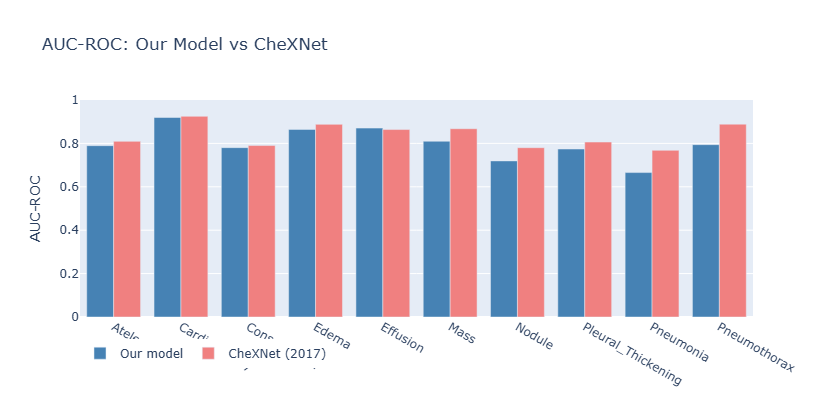

In [7]:
# Published CheXNet AUC scores for comparison
cheXnet_auc = {
    'Atelectasis': 0.8094, 'Cardiomegaly': 0.9248,
    'Consolidation': 0.7901, 'Edema': 0.8878,
    'Effusion': 0.8638, 'Mass': 0.8676,
    'Nodule': 0.7802, 'Pleural_Thickening': 0.8062,
    'Pneumonia': 0.7680, 'Pneumothorax': 0.8887,
}

fig = go.Figure()
fig.add_trace(go.Bar(
    name='Our model', x=PATHOLOGY_CLASSES,
    y=[metrics.auc_per_class.get(c, 0) for c in PATHOLOGY_CLASSES],
    marker_color='steelblue'
))
fig.add_trace(go.Bar(
    name='CheXNet (2017)', x=PATHOLOGY_CLASSES,
    y=[cheXnet_auc.get(c, 0) for c in PATHOLOGY_CLASSES],
    marker_color='lightcoral'
))
fig.update_layout(
    barmode='group', title='AUC-ROC: Our Model vs CheXNet',
    yaxis=dict(range=[0, 1], title='AUC-ROC'),
    height=400, legend=dict(orientation='h')
)
fig.show()

## 4. ROC Curves

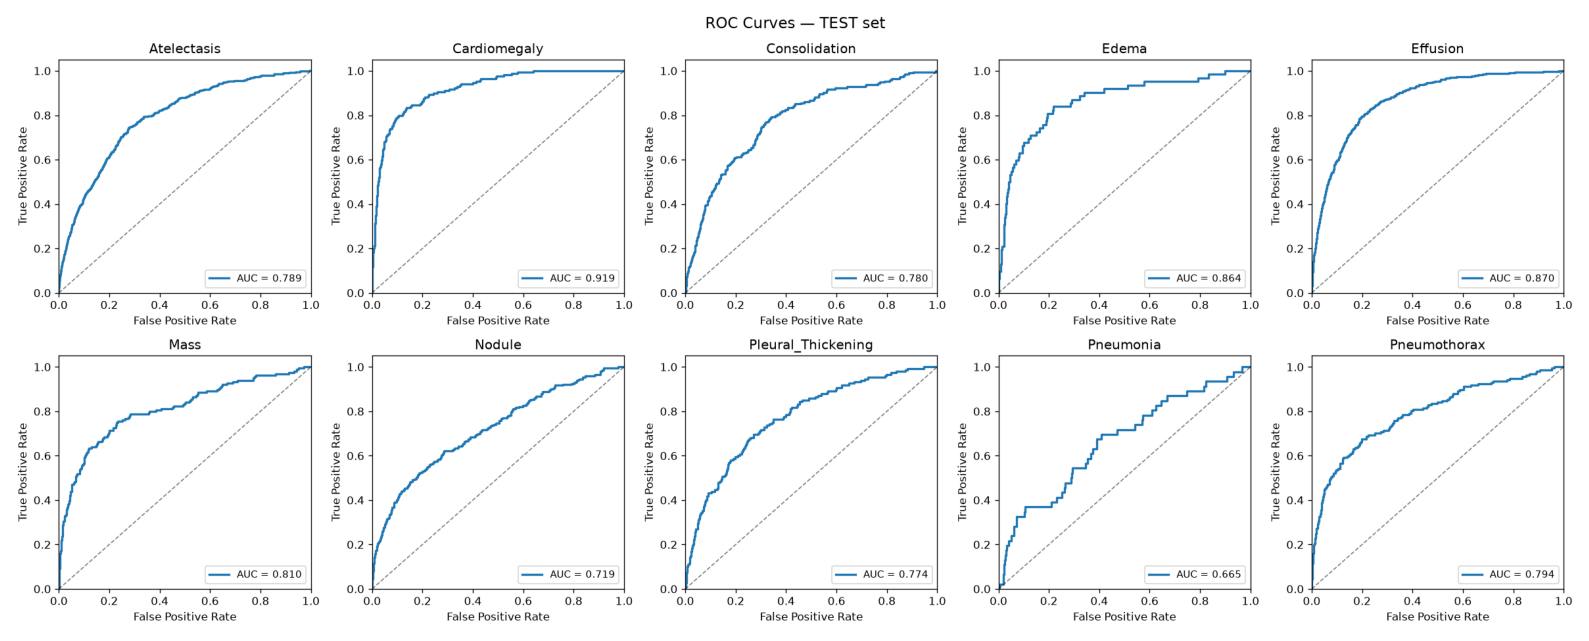

In [8]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

roc_path = Paths.processed / 'roc_curves_test.png'
if roc_path.exists():
    img = Image.open(roc_path)
    plt.figure(figsize=(16, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Run evaluate_on_test_set(save_plots=True) first')

## 5. Summary Table

In [9]:
from src.models.metrics import metrics_to_dataframe
df = metrics_to_dataframe(metrics)
df.round(4).style.highlight_max(subset=['auc', 'f1'], color='lightgreen')

,class,auc,auprc,precision,recall,f1
0,Cardiomegaly,0.919300,0.401700,0.268800,0.739600,0.394300
1,Effusion,0.870400,0.442800,0.330400,0.718500,0.452700
2,Edema,0.864400,0.116800,0.127400,0.532300,0.205600
3,Mass,0.809900,0.239600,0.177100,0.518300,0.264000
4,Pneumothorax,0.794200,0.210300,0.138200,0.566900,0.222200
5,Atelectasis,0.789500,0.302100,0.227400,0.662300,0.338500
6,Consolidation,0.780400,0.142900,0.116300,0.582500,0.193800
7,Pleural_Thickening,0.774100,0.117600,0.111500,0.439200,0.177800
8,Nodule,0.719200,0.187600,0.147300,0.454200,0.222400
9,Pneumonia,0.665500,0.023800,0.042700,0.217400,0.071400
